# Online Marketplace Product and Customer Revenue Analysis

## Business Question
Which products and customer groups contribute the most net sales revenue, and how much revenue is generated by repeat customers compared with one-time customers?

## Initial Hypothesis
A relatively small group of products and repeat customers contributes a disproportionately large share of total net sales revenue.

## Dataset
This project uses a synthetic online marketplace orders dataset containing 18,000 orders from 2022 through 2025.

**Source:** [Online Marketplace Orders Dataset on Kaggle](https://www.kaggle.com/datasets/mmumairkhattak/online-marketplace-orders-dataset)

**License:** MIT License

In [66]:
from google.colab import files

uploaded = files.upload()

Saving online_marketplace_orders.csv to online_marketplace_orders (2).csv


In [67]:
import pandas as pd

file_name = "online_marketplace_orders.csv"
df = pd.read_csv(file_name)

print("Data loaded successfully.")
print("Number of rows:",df.shape[0])
print("Number of columns:", df.shape[1])

Data loaded successfully.
Number of rows: 18000
Number of columns: 39


In [68]:
df.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Product_Category,Seller_Type,Customer_Region,Seller_Region,Sales_Channel,Payment_Method,...,Shipping_Fee,Cancellation_Flag,Return_Flag,Customer_Satisfaction_Score,Order_Status,Seller_Performance_Score,Order_Hour,Day_of_Week,Month,Year
0,MKP00000001,2022-01-01 00:00:00,CUST05799,PROD01843,Home & Kitchen,Small Business,North,North,Web,Debit Card,...,14.56,0,0,4.26,Completed,67.92,0,5,1,2022
1,MKP00000002,2022-01-01 01:56:48,CUST01009,PROD02147,Grocery,Enterprise Seller,East,West,Mobile App,Debit Card,...,26.97,0,0,4.69,Completed,72.95,1,5,1,2022
2,MKP00000003,2022-01-01 03:53:36,CUST03740,PROD02261,Home & Kitchen,Brand Store,East,South,Web,Digital Wallet,...,19.31,0,0,4.78,Completed,87.60,3,5,1,2022
3,MKP00000004,2022-01-01 05:50:25,CUST02359,PROD03139,Toys & Games,Brand Store,East,Central,Web,Debit Card,...,12.13,0,0,3.43,Completed,53.83,5,5,1,2022
4,MKP00000005,2022-01-01 07:47:13,CUST04321,PROD02348,Fashion,Individual Seller,East,West,Web,Credit Card,...,9.75,0,1,4.24,Returned,68.20,7,5,1,2022


## 1. Data Understanding and Validation

The dataset was inspected to understand its structure, data types, missing values, and unique-value counts before performing analysis.

In [69]:
column_summary = pd.DataFrame({
    "Column_Name": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Values": df.isnull().sum().values,
    "Unique_Values": df.nunique().values
})

column_summary


,Column_Name,Data_Type,Missing_Values,Unique_Values
0,Order_ID,object,0,18000
1,Order_Date,object,0,18000
2,Customer_ID,object,0,6068
3,Product_ID,object,0,4143
4,Product_Category,object,0,10
5,Seller_Type,object,0,4
6,Customer_Region,object,0,5
7,Seller_Region,object,0,5
8,Sales_Channel,object,0,4
9,Payment_Method,object,0,5


In [70]:
print("Order_Date data type:", df["Order_Date"].dtype)

Order_Date data type: object


In [71]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

print("Order_Date data type:", df["Order_Date"].dtype)
print("Invalid or missing dates:", df["Order_Date"].isnull().sum())
print("Earliest order date:", df["Order_Date"].min())
print("Latest order date:", df["Order_Date"].max())

Order_Date data type: datetime64[ns]
Invalid or missing dates: 0
Earliest order date: 2022-01-01 00:00:00
Latest order date: 2025-12-31 00:00:00


In [72]:
incorrect_years = (df["Order_Date"].dt.year != df["Year"]).sum()

print("Rows with incorrect year values:", incorrect_years)

Rows with incorrect year values: 0


## 2. Creating the SQL Database

After validating the imported data and converting the order date, the cleaned dataset was loaded into a SQLite database for SQL analysis.

In [73]:
import sqlite3

connection = sqlite3.connect("online_marketplace.db")

df.to_sql(
    name="orders",
    con=connection,
    if_exists="replace",
    index=False
)

print("SQL table created successfully.")

SQL table created successfully.


In [74]:
query = """
SELECT COUNT(*) AS number_of_records
FROM orders;
"""

pd.read_sql_query(query, connection)

,number_of_records
0,18000


### 2.1 Overall Business Summary

The first SQL query calculates the total number of orders, customers, products, total net sales revenue, and average order value.

In [75]:
query = """
SELECT
  COUNT(*) AS Total_Orders,
  COUNT(DISTINCT Customer_ID) AS Unique_Customers,
  COUNT(DISTINCT Product_ID) AS Unique_Products,
  ROUND(SUM(Net_Order_Value),2) AS Total_Net_Revenue,
  ROUND(AVG(Net_Order_Value),2) AS Average_Order_Value
FROM orders;
"""

business_summary = pd.read_sql_query(query, connection)
business_summary

,Total_Orders,Unique_Customers,Unique_Products,Total_Net_Revenue,Average_Order_Value
0,18000,6068,4143,2612304.41,145.13


### 2.2 Repeat Customers versus One-Time Customers

Customers were classified according to their total number of orders:

- One-time customer: placed exactly one order
- Repeat customer: placed two or more orders

In [76]:
query = """
WITH customer_summary AS (
  SELECT
    Customer_ID,
    COUNT(*) AS Order_Count,
    SUM(Net_Order_Value) AS Customer_Revenue
  FROM orders
  GROUP BY Customer_ID
),

customer_classification AS(
  SELECT
    Customer_ID,
    Order_Count,
    Customer_Revenue,
    CASE
      WHEN Order_count = 1 THEN 'One-time customer'
      ELSE 'Repeat customer'
    END AS Customer_Type
  FROM customer_summary
  )

  SELECT
    Customer_Type,
    COUNT(*) AS Number_of_Customers,
    SUM(Order_Count) AS Number_of_Orders,
    ROUND(SUM(Customer_Revenue),2) AS Total_Net_Revenue,
    ROUND(SUM(Customer_Revenue)/SUM(Order_Count), 2) AS Average_Order_Value,
    ROUND(
      100.0* SUM(Customer_Revenue)/(SELECT SUM(Net_Order_Value) FROM orders), 2
      ) AS Revenue_Share_Percent
      FROM customer_classification
  GROUP BY Customer_Type
  ORDER BY Total_Net_Revenue DESC;
"""

customer_type_summary  = pd.read_sql_query(query, connection)
customer_type_summary

,Customer_Type,Number_of_Customers,Number_of_Orders,Total_Net_Revenue,Average_Order_Value,Revenue_Share_Percent
0,Repeat customer,4998,16930,2462898.06,145.48,94.28
1,One-time customer,1070,1070,149406.35,139.63,5.72


#### Initial Customer Finding

Repeat customers generated 94.28% of total net sales revenue and placed 16,930 of the 18,000 orders. Their average order value was $145.48, compared with $139.63 for one-time customers. Therefore, their revenue contribution was driven mainly by repeat purchasing rather than a substantially higher individual order value. However, repeat customers represented 82.37% of all customers, so they were not a small customer group.

### 2.3 Product ID–Category Data Quality Check

In [77]:
query = """
WITH product_category_check AS (
    SELECT
        Product_ID,
        COUNT(DISTINCT Product_Category) AS Category_Count
    FROM orders
    GROUP BY Product_ID
)

SELECT
    COUNT(*) AS Total_Product_IDs,
    SUM(
        CASE
            WHEN Category_Count > 1 THEN 1
            ELSE 0
        END
    ) AS Products_With_Multiple_Categories,
    MAX(Category_Count) AS Maximum_Categories_Per_Product
FROM product_category_check;
"""

product_category_validation = pd.read_sql_query(query, connection)
product_category_validation

,Total_Product_IDs,Products_With_Multiple_Categories,Maximum_Categories_Per_Product
0,4143,3797,9


The validation found that 3,797 of the 4,143 Product IDs were associated with multiple categories, with some Product IDs appearing in as many as nine categories. Therefore, Product ID and Product Category could not be treated as a reliable product-category mapping.

### 2.4 Highest-Revenue Products

Products were grouped by Product ID and ranked according to total net sales revenue to identify the ten highest-revenue products.

In [78]:
query = """
SELECT
    Product_ID,
    COUNT(*) AS Number_of_Orders,
    SUM(Order_Quantity) AS Units_Ordered,
    ROUND(SUM(Net_Order_Value), 2) AS Total_Net_Revenue,
    ROUND(AVG(Net_Order_Value), 2) AS Average_Order_Value
FROM orders
GROUP BY Product_ID
ORDER BY Total_Net_Revenue DESC
LIMIT 10;
"""

top_products = pd.read_sql_query(query, connection)
top_products

,Product_ID,Number_of_Orders,Units_Ordered,Total_Net_Revenue,Average_Order_Value
0,PROD03184,4,21,3593.78,898.44
1,PROD03138,7,27,3563.38,509.05
2,PROD02995,6,16,3021.59,503.60
3,PROD04009,10,37,2990.02,299.00
4,PROD02950,7,29,2989.15,427.02
5,PROD01416,9,28,2804.81,311.65
6,PROD02933,11,35,2730.60,248.24
7,PROD01745,4,19,2707.98,677.00
8,PROD03395,4,15,2692.05,673.01
9,PROD01247,6,29,2513.16,418.86


### 2.5 Product Revenue Concentration

Products were ranked by total net sales revenue and divided into ten approximately equal groups. The highest-revenue 10% of products were then compared with overall marketplace revenue.

In [79]:
query = """
WITH product_summary AS (
    SELECT
        Product_ID,
        SUM(Net_Order_Value) AS Product_Revenue
    FROM orders
    GROUP BY Product_ID
),

ranked_products AS (
    SELECT
        Product_ID,
        Product_Revenue,
        NTILE(10) OVER (
            ORDER BY Product_Revenue DESC
        ) AS Revenue_Decile,
        COUNT(*) OVER () AS Total_Products,
        SUM(Product_Revenue) OVER () AS Overall_Revenue
    FROM product_summary
)

SELECT
    COUNT(*) AS Products_in_Top_10_Percent,
    MAX(Total_Products) AS Total_Products,
    ROUND(SUM(Product_Revenue), 2) AS Top_10_Percent_Revenue,
    ROUND(
        100.0 * SUM(Product_Revenue) / MAX(Overall_Revenue),
        2
    ) AS Revenue_Share_Percent
FROM ranked_products
WHERE Revenue_Decile = 1;
"""

product_concentration = pd.read_sql_query(query, connection)
product_concentration

,Products_in_Top_10_Percent,Total_Products,Top_10_Percent_Revenue,Revenue_Share_Percent
0,415,4143,653961.46,25.03


#### Product-Concentration Finding

The highest-revenue 10% of products consisted of 415 of the 4,143 unique products and generated $653,961.46, representing 25.03% of total net sales revenue. This supports the hypothesis that a relatively small group of products contributes a disproportionately large revenue share, although revenue was not extremely concentrated.

A data-quality check found that 3,797 of the 4,143 Product IDs, approximately 91.65%, were associated with multiple product categories. Therefore, product-level analysis used Product ID alone, while category analysis was kept separate.

### 2.6 Customer Revenue Concentration

In [80]:
query = """
WITH customer_summary AS (
    SELECT
        Customer_ID,
        COUNT(*) AS Order_Count,
        SUM(Net_Order_Value) AS Customer_Revenue
    FROM orders
    GROUP BY Customer_ID
),

ranked_customers AS (
    SELECT
        Customer_ID,
        Order_Count,
        Customer_Revenue,
        NTILE(10) OVER (
            ORDER BY Customer_Revenue DESC
        ) AS Revenue_Decile,
        COUNT(*) OVER () AS Total_Customers,
        SUM(Customer_Revenue) OVER () AS Overall_Revenue
    FROM customer_summary
)

SELECT
    COUNT(*) AS Customers_in_Top_10_Percent,
    MAX(Total_Customers) AS Total_Customers,
    SUM(Order_Count) AS Orders_from_Top_Customers,
    ROUND(SUM(Customer_Revenue), 2) AS Top_10_Percent_Revenue,
    ROUND(
        100.0 * SUM(Customer_Revenue) / MAX(Overall_Revenue),
        2
    ) AS Revenue_Share_Percent
FROM ranked_customers
WHERE Revenue_Decile = 1;
"""

customer_concentration = pd.read_sql_query(query, connection)
customer_concentration

,Customers_in_Top_10_Percent,Total_Customers,Orders_from_Top_Customers,Top_10_Percent_Revenue,Revenue_Share_Percent
0,607,6068,2962,749364.7,28.69


#### Customer-Concentration Finding

The highest-revenue 10% of customers consisted of 607 of the 6,068 customers. They placed 2,962 orders and generated \$749,364.70, representing 28.69\%  of total net sales revenue.
These customers accounted for approximately 16.46\% of orders but had an average order value of approximately \$252.99, compared with the marketplace-wide average of \$145.13. Their high revenue contribution was therefore associated with both purchasing frequency and higher-value orders.

### 2.7 Composition of the Highest-Revenue Customer Group

In [81]:
query = """
WITH customer_summary AS (
    SELECT
        Customer_ID,
        COUNT(*) AS Order_Count,
        SUM(Net_Order_Value) AS Customer_Revenue
    FROM orders
    GROUP BY Customer_ID
),

ranked_customers AS (
    SELECT
        Customer_ID,
        Order_Count,
        Customer_Revenue,
        NTILE(10) OVER (
            ORDER BY Customer_Revenue DESC
        ) AS Revenue_Decile
    FROM customer_summary
)

SELECT
    CASE
        WHEN Order_Count = 1 THEN 'One-time Customer'
        ELSE 'Repeat Customer'
    END AS Customer_Type,
    COUNT(*) AS Number_of_Customers,
    SUM(Order_Count) AS Number_of_Orders,
    ROUND(SUM(Customer_Revenue), 2) AS Total_Net_Revenue
FROM ranked_customers
WHERE Revenue_Decile = 1
GROUP BY Customer_Type
ORDER BY Total_Net_Revenue DESC;
"""

top_customer_types = pd.read_sql_query(query, connection)
top_customer_types

,Customer_Type,Number_of_Customers,Number_of_Orders,Total_Net_Revenue
0,Repeat Customer,603,2958,745407.97
1,One-time Customer,4,4,3956.73


#### Top-Customer Composition

Of the 607 customers in the highest-revenue 10%, 603 were repeat customers and only four were one-time customers. Repeat customers generated approximately 99.47% of this group’s revenue. This strongly supports the hypothesis that repeat purchasing is associated with the marketplace’s highest-revenue customers.

### 2.8 Product-Category Revenue Analysis

Order-level product categories were compared using total net revenue, order volume, units ordered, revenue share, and average order value.

In [82]:
query = """
SELECT
    Product_Category,
    COUNT(*) AS Number_of_Orders,
    SUM(Order_Quantity) AS Units_Ordered,
    ROUND(SUM(Net_Order_Value), 2) AS Total_Net_Revenue,
    ROUND(
        100.0 * SUM(Net_Order_Value) /
        (SELECT SUM(Net_Order_Value) FROM orders),
        2
    ) AS Revenue_Share_Percent,
    ROUND(AVG(Net_Order_Value), 2) AS Average_Order_Value
FROM orders
GROUP BY Product_Category
ORDER BY Total_Net_Revenue DESC;
"""

category_summary = pd.read_sql_query(query, connection)
category_summary

,Product_Category,Number_of_Orders,Units_Ordered,Total_Net_Revenue,Revenue_Share_Percent,Average_Order_Value
0,Fashion,2922,8871,427214.22,16.35,146.21
1,Electronics,2487,7617,378111.97,14.47,152.04
2,Home & Kitchen,2329,6949,337340.27,12.91,144.84
3,Beauty,2151,6366,314855.67,12.05,146.38
4,Books,1772,5271,257752.34,9.87,145.46
5,Sports,1610,4776,219495.54,8.40,136.33
6,Toys & Games,1517,4514,213491.00,8.17,140.73
7,Grocery,1449,4371,204979.81,7.85,141.46
8,Accessories,1083,3156,157532.07,6.03,145.46
9,Automotive,680,2066,101531.52,3.89,149.31


#### Product-Category Finding

Fashion generated the highest net revenue at \$427,214.22, representing 16.35% of total revenue, followed by Electronics at 14.47%. The four leading categories—Fashion, Electronics, Home & Kitchen, and Beauty—contributed a combined 55.78% of revenue. Category revenue differences were driven mainly by order volume because average order values were relatively similar. Electronics recorded the highest average order value at \$152.04.

## 3. Python Data Visualization

Three charts were created to communicate product-category performance, customer-type revenue, and revenue concentration among the highest-revenue 10% of products and customers.

### 3.1 Net Revenue by Product Category

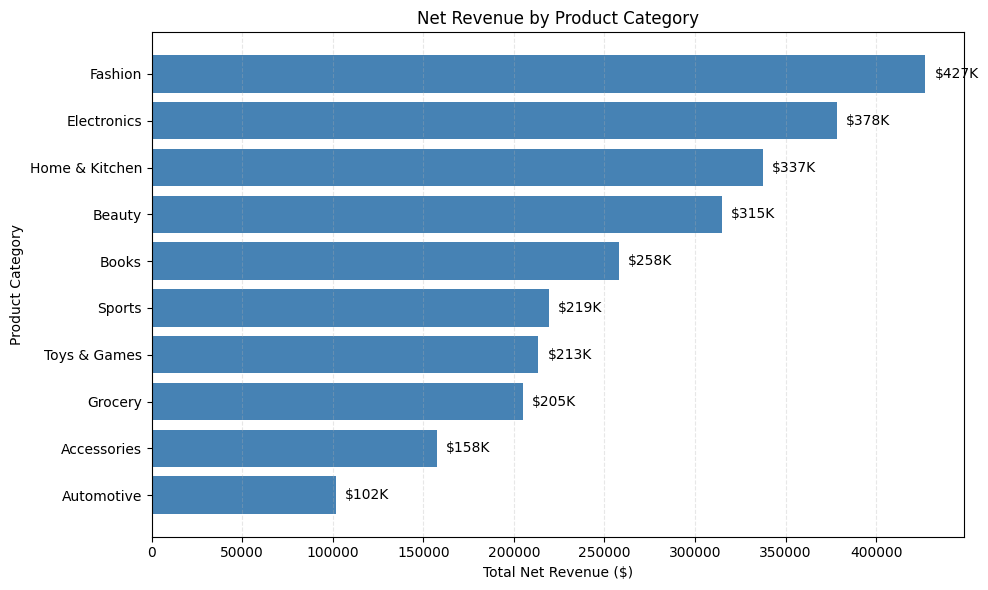

In [83]:
import matplotlib.pyplot as plt

category_plot = category_summary.sort_values(
    "Total_Net_Revenue",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    category_plot["Product_Category"],
    category_plot["Total_Net_Revenue"],
    color="steelblue"
)

plt.title("Net Revenue by Product Category")
plt.xlabel("Total Net Revenue ($)")
plt.ylabel("Product Category")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar in bars:
    revenue = bar.get_width()

    plt.text(
        revenue + 5000,
        bar.get_y() + bar.get_height() / 2,
        f"${revenue / 1000:.0f}K",
        va="center"
    )

plt.tight_layout()
plt.show()

### 3.2 Net Revenue by Customer Type

A bar chart was created to compare net revenue generated by repeat and one-time customers.

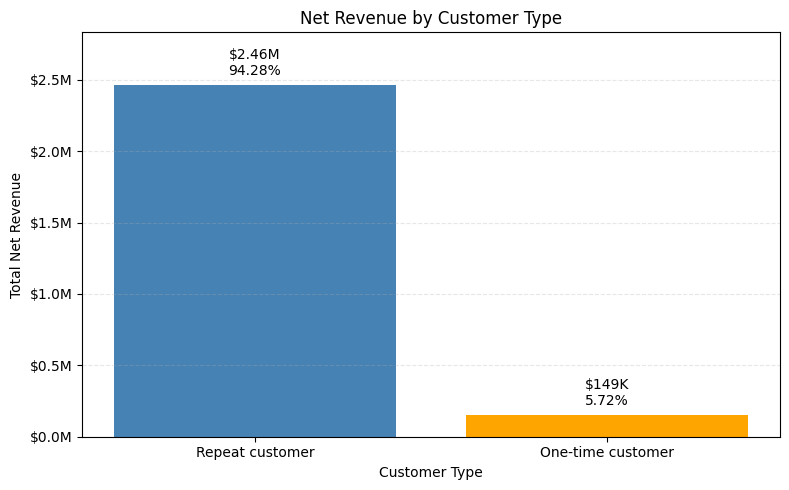

In [84]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

customer_chart = customer_type_summary.copy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    customer_chart["Customer_Type"],
    customer_chart["Total_Net_Revenue"],
    color=["steelblue", "orange"]
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
        f"${value / 1_000_000:.1f}M"
    )
)

plt.title("Net Revenue by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Net Revenue")
plt.grid(axis="y", linestyle="--", alpha=0.3)

maximum_revenue = customer_chart[
    "Total_Net_Revenue"
].max()

for bar, revenue, share in zip(
    bars,
    customer_chart["Total_Net_Revenue"],
    customer_chart["Revenue_Share_Percent"]
):
    if revenue >= 1_000_000:
        revenue_label = (
            f"${revenue / 1_000_000:.2f}M"
        )
    else:
        revenue_label = (
            f"${revenue / 1_000:.0f}K"
        )

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + maximum_revenue * 0.02,
        f"{revenue_label}\n{share:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, maximum_revenue * 1.15)
plt.tight_layout()
plt.show()

### 3.3 Revenue Concentration in the Top 10%

A bar chart was created to compare the revenue contribution of the highest-revenue 10% of products and customers.

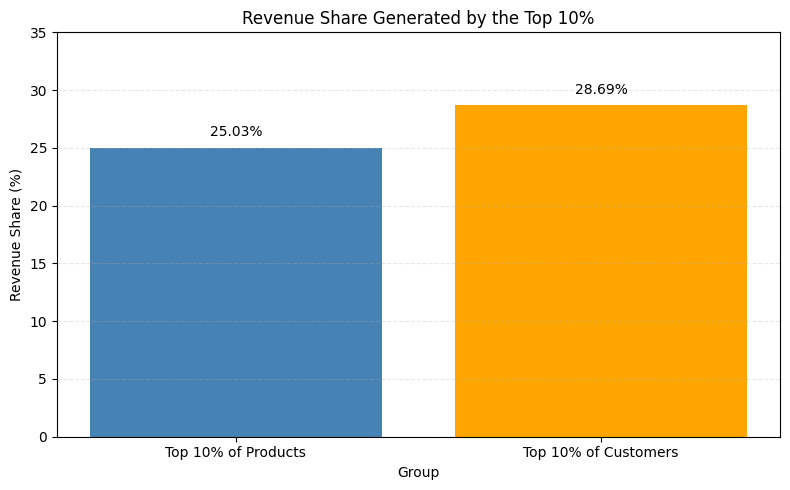

In [85]:
concentration_chart = pd.DataFrame({
    "Group": [
        "Top 10% of Products",
        "Top 10% of Customers"
    ],
    "Revenue_Share_Percent": [
        product_concentration.loc[
            0, "Revenue_Share_Percent"
        ],
        customer_concentration.loc[
            0, "Revenue_Share_Percent"
        ]
    ]
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    concentration_chart["Group"],
    concentration_chart["Revenue_Share_Percent"],
    color=["steelblue", "orange"]
)

plt.title("Revenue Share Generated by the Top 10%")
plt.xlabel("Group")
plt.ylabel("Revenue Share (%)")
plt.ylim(0, 35)
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, share in zip(
    bars,
    concentration_chart["Revenue_Share_Percent"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.7,
        f"{share:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 4. Python Validation of SQL Findings

The customer-level SQL analysis was reproduced using pandas to confirm the results and demonstrate data aggregation and classification in Python.

In [86]:
customer_python = (
    df.groupby("Customer_ID")
      .agg(
          Order_Count=("Order_ID", "count"),
          Customer_Revenue=("Net_Order_Value", "sum")
      )
      .reset_index()
)

customer_python.head()

,Customer_ID,Order_Count,Customer_Revenue
0,CUST00001,1,127.78
1,CUST00002,3,439.73
2,CUST00003,4,627.23
3,CUST00004,5,1778.49
4,CUST00007,3,557.18


In [87]:
print("Number of customers:", customer_python.shape[0])
print("Total orders:", customer_python["Order_Count"].sum())
print(
    "Total revenue:",
    round(customer_python["Customer_Revenue"].sum(), 2)
)

Number of customers: 6068
Total orders: 18000
Total revenue: 2612304.41


In [88]:
##  1. Classify customers
import numpy as np

customer_python["Customer_Type"] = np.where(
    customer_python["Order_Count"] == 1,
    "One-time Customer",
    "Repeat Customer"
)

customer_python.head()

,Customer_ID,Order_Count,Customer_Revenue,Customer_Type
0,CUST00001,1,127.78,One-time Customer
1,CUST00002,3,439.73,Repeat Customer
2,CUST00003,4,627.23,Repeat Customer
3,CUST00004,5,1778.49,Repeat Customer
4,CUST00007,3,557.18,Repeat Customer


In [89]:
##  2. Summarize each customer type
customer_type_python = (
    customer_python.groupby("Customer_Type")
    .agg(
        Number_of_Customers=("Customer_ID", "count"),
        Number_of_Orders=("Order_Count", "sum"),
        Total_Net_Revenue=("Customer_Revenue", "sum")
    )
    .reset_index()
)

customer_type_python

,Customer_Type,Number_of_Customers,Number_of_Orders,Total_Net_Revenue
0,One-time Customer,1070,1070,149406.35
1,Repeat Customer,4998,16930,2462898.06


In [90]:
##  3. Calculate AOV and revenue share
customer_type_python["Average_Order_Value"] = (
    customer_type_python["Total_Net_Revenue"]
    / customer_type_python["Number_of_Orders"]
).round(2)

overall_revenue = customer_type_python["Total_Net_Revenue"].sum()

customer_type_python["Revenue_Share_Percent"] = (
    customer_type_python["Total_Net_Revenue"]
    / overall_revenue
    * 100
).round(2)

customer_type_python["Total_Net_Revenue"] = (
    customer_type_python["Total_Net_Revenue"].round(2)
)

customer_type_python = customer_type_python.sort_values(
    "Total_Net_Revenue",
    ascending=False
)

customer_type_python

,Customer_Type,Number_of_Customers,Number_of_Orders,Total_Net_Revenue,Average_Order_Value,Revenue_Share_Percent
1,Repeat Customer,4998,16930,2462898.06,145.48,94.28
0,One-time Customer,1070,1070,149406.35,139.63,5.72


#### SQL and Python Validation

The pandas analysis reproduced the SQL customer-type results exactly. Repeat customers accounted for 4,998 customers, 16,930 orders, and 94.28% of total net revenue. This confirms that the customer classification and aggregation were consistent across both tools.

In [91]:
## 1. Creating one row per product

product_python = (
    df.groupby("Product_ID")
    .agg(
        Number_of_Orders=("Order_ID", "count"),
        Units_Ordered=("Order_Quantity", "sum"),
        Total_Net_Revenue=("Net_Order_Value", "sum")
    )
    .reset_index()
    .sort_values(
        "Total_Net_Revenue",
        ascending=False
    )
)

product_python.head()

,Product_ID,Number_of_Orders,Units_Ordered,Total_Net_Revenue
3142,PROD03184,4,21,3593.78
3097,PROD03138,7,27,3563.38
2956,PROD02995,6,16,3021.59
3955,PROD04009,10,37,2990.02
2911,PROD02950,7,29,2989.15


In [92]:
##  2. Select the highest-revenue 10%
top_product_count = int(
    np.ceil(len(product_python) * 0.10)
)

top_10_percent_products = product_python.head(
    top_product_count
)

print("Total products:", len(product_python))
print("Products in top 10%:", top_product_count)

Total products: 4143
Products in top 10%: 415


In [93]:
## 3. Calculate their revenue share
top_product_revenue = (
    top_10_percent_products["Total_Net_Revenue"].sum()
)

overall_product_revenue = (
    product_python["Total_Net_Revenue"].sum()
)

top_product_revenue_share = (
    top_product_revenue
    / overall_product_revenue
    * 100
)

print(
    "Top 10% product revenue:",
    round(top_product_revenue, 2)
)

print(
    "Revenue share percentage:",
    round(top_product_revenue_share, 2)
)

Top 10% product revenue: 653961.46
Revenue share percentage: 25.03


#### Product-Concentration Validation

The pandas product analysis reproduced the SQL results. The highest-revenue 10% consisted of 415 of the 4,143 products and generated $653,961.46, representing 25.03% of total net revenue.

## 5. Hypothesis Evaluation

The initial hypothesis proposed that a relatively small group of high-performing products and repeat customers contributes a disproportionately large share of total net sales revenue.

The product portion of the hypothesis was supported. The highest-revenue 10% of products consisted of 415 products and generated 25.03% of total net revenue. This contribution was approximately 2.5 times the share expected under an even revenue distribution, although revenue was not extremely concentrated among products.

The repeat-customer portion was also supported, with an important qualification. Repeat customers generated 94.28% of total net revenue and accounted for 603 of the 607 customers in the highest-revenue 10%. However, repeat customers represented 82.37% of all customers, meaning they were not a small customer group.

Overall, the analysis supports the conclusion that repeat purchasing and higher-performing products are important revenue drivers. The results also show that the highest-revenue customers combine frequent purchasing with higher-value orders.

## 6. Business Recommendations

1. Prioritize customer retention because repeat customers generated 94.28% of total net revenue.

2. Develop targeted loyalty and personalized promotion strategies for high-value repeat customers. The highest-revenue 10% of customers generated 28.69% of total revenue.

3. Encourage one-time customers to make a second purchase through follow-up offers, loyalty enrollment, or product recommendations.

4. Maintain strong availability and visibility for the highest-revenue products, because the top 10% of products generated 25.03% of total revenue.

5. Give particular attention to Fashion and Electronics. Fashion generated the highest category revenue, while Electronics had the highest average order value.

6. Improve product master-data quality before making detailed product-category decisions, because 3,797 of the 4,143 Product IDs were associated with multiple categories.

## 7. Project Limitations

1. The dataset is synthetic rather than actual marketplace data. Therefore, the findings demonstrate analytical methods but should not be treated as evidence of real customer behavior.

2. 3,797 of the 4,143 Product IDs, approximately 91.65%, were associated with multiple product categories. Therefore, product-level analysis was performed using Product ID alone, while product-category analysis was conducted separately at the order level.

3. Net Order Value was used as the primary revenue measure. The dataset does not provide sufficient product-cost information to evaluate profitability, so high-revenue products should not be described as the most profitable products.

4. Customers were classified using orders recorded between January 1, 2022, and December 31, 2025. A customer classified as one-time may have purchased before or after this observation period.

5. The analysis identifies associations and revenue patterns but does not prove that repeat purchasing or a particular product category caused higher revenue.

6. The dataset contained no missing values and very few calculation inconsistencies beyond immaterial rounding differences. This unusually clean condition may not represent the quality of real operational data.